# Advanced EDA and Feature Modification for Predictive Modelling

## Learning Objectives

- Understand the importance of EDA before model building.
- Explore and interpret the distribution of variables.
- Apply feature engineering techniques to improve linear model fit.
- Train, test and evaluate regression models.
- Reflect on the impact of the modification of features.

---

## Real-World Context

You are a data scientist investigating how a single variable (e.g. years of work experience) predicts salary for a group of employees. However, the relationship is not simple or linear. In this practical, you will explore and engineer features to improve predictive performance, using simulated data.

---


In [12]:
# 1. Data Simulation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(0)

# Simulate right-skewed predictor (e.g., years of experience)
X = np.random.exponential(scale=2, size=500) * 20

# Simulate salary with a non-linear relationship + noise
y = 2000 + 800 * np.log(X + 1) + np.random.normal(0, 500, size=X.shape[0])

# Create DataFrame
df = pd.DataFrame({'Experience': X, 'Salary': y})

df.head()

,Experience,Salary
0,31.834980,4300.440168
1,50.237231,4413.255637
2,36.928926,5732.638695
3,31.488046,4866.811645
4,22.041940,4793.497953


## 2. Initial EDA: Understanding the Data

In [13]:
display(df.describe())
print(df.isnull().sum())

,Experience,Salary
count,500.000000,500.000000
mean,40.346997,4517.673620
std,40.906651,1018.787494
min,0.188261,810.183426
25%,11.391535,3876.501386
50%,26.686967,4511.493761
75%,52.483972,5267.255008
max,270.615749,6770.354631


Experience    0
Salary        0
dtype: int64


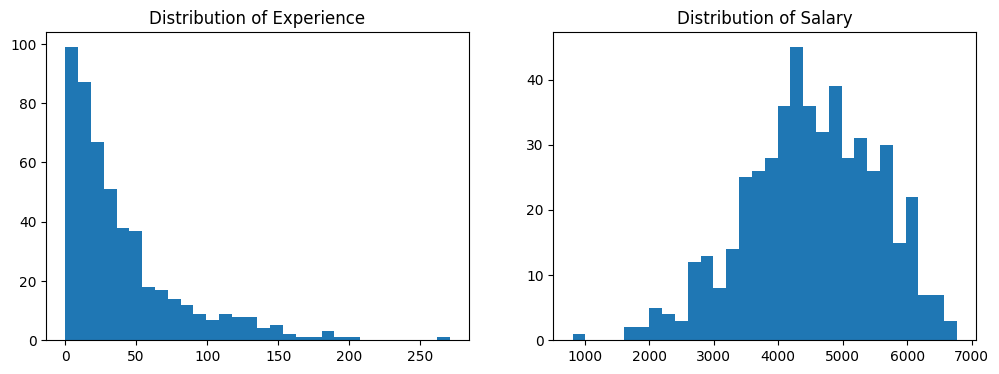

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(df['Experience'], bins=30)
ax[0].set_title('Distribution of Experience')
ax[1].hist(df['Salary'], bins=30)
ax[1].set_title('Distribution of Salary')
plt.show()

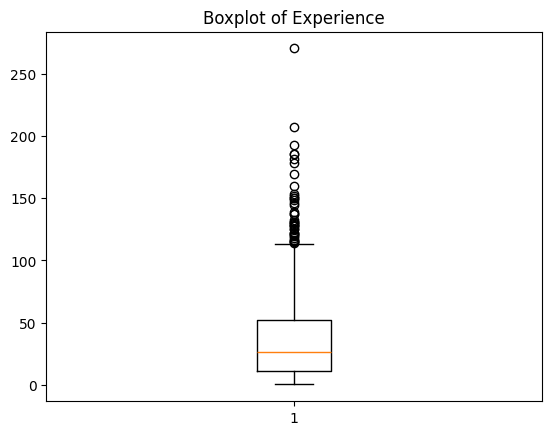

In [15]:
plt.boxplot(df['Experience'])
plt.title('Boxplot of Experience')
plt.show()

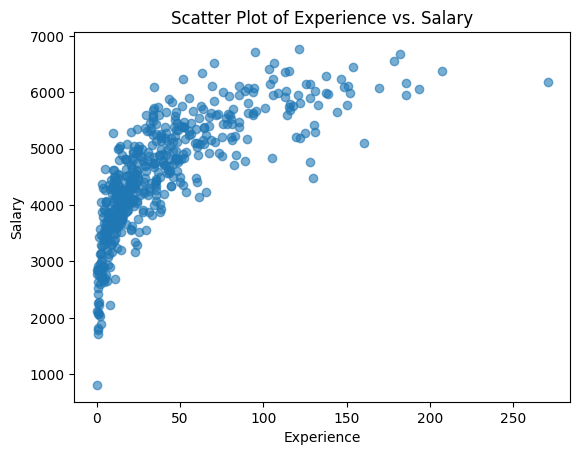

In [16]:
plt.scatter(df['Experience'], df['Salary'], alpha=0.6)
plt.title('Scatter Plot of Experience vs. Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

### Student Reflection
- What do you observe about the distribution of Experience?
- Is the relationship between Experience and Salary linear? Explain your answer.
---


<font color=red> univariate distribution does not show much insight for linear fitting. skewness does not correlate to good or poor linear fit. bivariate distribution against target is more meaningful. as it is, experience does not show a linear relationship with salary.

## 3. Baseline Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_raw = df[['Experience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2_raw = r2_score(y_test, y_pred)
print(f'R² = {r2_raw:.3f}')

R² = 0.523


### Student Reflection
- Based on the scatter plot and model results, is linear regression a good fit? Why or why not?
---


<font color=red> as expected, poor fit, r2 value is low. tutor can ask about how can we visualise the fit. example, residual plot, etc. do not need to show at this stage. will show in sessions later.

## 4. Feature Engineering: Log Transformation

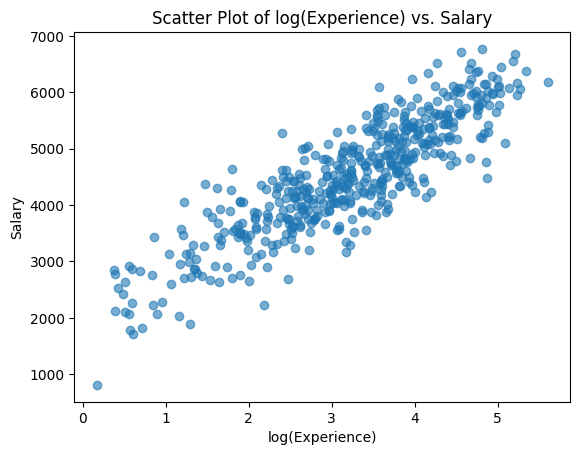

In [18]:
df['log_Experience'] = np.log(df['Experience'] + 1)
plt.scatter(df['log_Experience'], df['Salary'], alpha=0.6)
plt.title('Scatter Plot of log(Experience) vs. Salary')
plt.xlabel('log(Experience)')
plt.ylabel('Salary')
plt.show()

In [19]:
X_log = df[['log_Experience']]
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, random_state=42)

lr_log = LinearRegression()
lr_log.fit(X_train, y_train)
y_pred_log = lr_log.predict(X_test)

r2_log = r2_score(y_test, y_pred_log)
print(f'R² = {r2_log:.3f}')

R² = 0.761


### Student Reflection
- Did the log transformation improve the model fit? Why or why not?
- What does this tell you about the nature of the relationship?
---


<font color=red> log experience is a good linear fit against salary. when train test evaluate against linear regression model, the r2 score improved.

## 5. Feature Engineering: Other Transformations

Lets try if other transformation will be useful, since in actual DS/ML project, we wont know if log X would be a better fit or not.

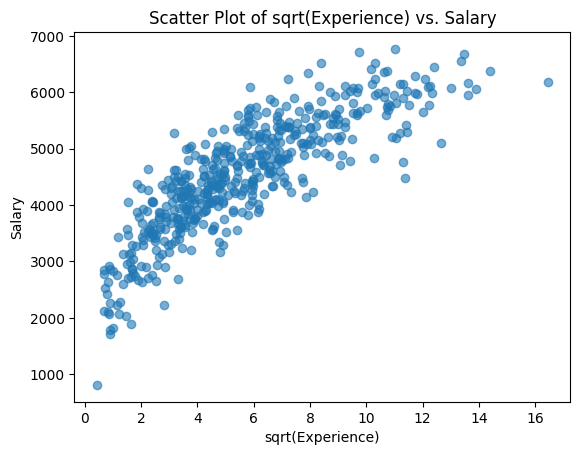

In [20]:
df['sqrt_Experience'] = np.sqrt(df['Experience'])
plt.scatter(df['sqrt_Experience'], df['Salary'], alpha=0.6)
plt.title('Scatter Plot of sqrt(Experience) vs. Salary')
plt.xlabel('sqrt(Experience)')
plt.ylabel('Salary')
plt.show()

In [21]:
X_sqrt = df[['sqrt_Experience']]
X_train, X_test, y_train, y_test = train_test_split(X_sqrt, y, test_size=0.2, random_state=42)

lr_sqrt = LinearRegression()
lr_sqrt.fit(X_train, y_train)
y_pred_sqrt = lr_sqrt.predict(X_test)

r2_sqrt = r2_score(y_test, y_pred_sqrt)
print(f'R² = {r2_sqrt:.3f}')
print(f'Raw R² = {r2_raw:.3f}')

R² = 0.689
Raw R² = 0.523


### Student Reflection
- Did the new transformation improve the model fit? Why or why not?
- What does this tell you about the nature of the relationship?
---


<font color=red> sqrt experience is only slightly a better linear fit against salary, compared to raw experince. of cos, when train test evaluate sqrt experience against linear regression model, the sqrt-exp r2 score improved, compared to raw-exp r2, but lower than log-exp r2. <br><br>
raw-exp > sqrt-exp > log-exp

## 6. Feature Engineering: What to Expect?

Again, since in actual DS/ML project, we wont know if any specific X would be a better fit or not, why not use the 'kitchen sink' approach, throw everything at it, to see what sticks?

In [22]:
X_mix = df[['sqrt_Experience','log_Experience','Experience']]
X_train, X_test, y_train, y_test = train_test_split(X_mix, y, test_size=0.2, random_state=42)

lr_mix = LinearRegression()
lr_mix.fit(X_train, y_train)
y_pred_mix = lr_mix.predict(X_test)

r2_mix = r2_score(y_test, y_pred_mix)
print(f'Mix R² = {r2_mix:.3f}')
print(f'log R² = {r2_log:.3f}')
print(f'sqrt R² = {r2_sqrt:.3f}')
print(f'Raw R² = {r2_raw:.3f}')

Mix R² = 0.759
log R² = 0.761
sqrt R² = 0.689
Raw R² = 0.523


<font color=red> mix r2 most likely did not improve from log r2, but exception possible, only due to random state issue (i.e.: mix r2 was lucky, but if u test over large number of random state, luck matter less (prelude to cross-validate)) <br> <br> how to tell which transformation contributed the most? we dun need to jump into feature importance or permutation feature importance yet, lucky for us, linear regression have coefficient to help us.

In [23]:
#print lr_mix.coef_ equation
for i in range(len(lr_mix.coef_)):
    print(f'{lr_mix.coef_[i]} * {X_mix.columns[i]}')
print(lr_mix.intercept_)

120.71964966186323 * sqrt_Experience
621.1475686093186 * log_Experience
-4.0927600003414 * Experience
2012.0806794957502


<font color=red> but is it a fair comparison? NO, because the predictors are not normalised, experience range is different from sqrt_ and log_experience. <br><br> next linear regression session, we will do a proper one with normalisation.

### Student Task
- Try at least one other transformation not listed above (e.g., exponential, reciprocal, etc.).
- Compare the R² for all models.
- Which transformation gives the best fit? Why do you think that is the case?

---
## 7. Reflection and Discussion

- Summarise what you have learned about the importance of feature engineering.
- How does EDA guide your choice of transformations?
- In a real-world setting, why might it be risky to apply transformations blindly?
- When would you stop feature engineering and move to more complex models?

---



<font color=red>  
## Kitchen Sink Approach: Pros & Cons

| Aspect                   | Pros                                                | Cons                                                                |
| ------------------------ | --------------------------------------------------- | ------------------------------------------------------------------- |
| **Model Expressiveness** | May capture hidden patterns that a human might miss | May also learn noise and assume it as correlations                      |
| **Speed of Prototyping** | Faster initial experimentation                      | Results in bloated models, **hard to interpret**                        |
| **Data Quality Control** | Reduces human bias in feature selection             | Often ignores domain knowledge for sake of chasing accuracy                                      |
| **Model Performance**    | Can improve complex models with large datasets      | Easily causes **overfitting**, especially on small datasets         |
| **Interpretability**     | Helps uncover unexpected signals                    | Makes explainability almost impossible (especially in XAI contexts) |


## ✅ Better Alternative: Informed Exploration
<font color=red>
Start wide, but not blind – include a reasonable set of raw and derived features. <br><br>
Check correlation and distribution – avoid redundant or highly skewed inputs unless you're transforming them. <br><br>
Use model-based feature selection – SHAP, permutation importance, or L1 regularisation. <br><br>
Validate iteratively – every new feature added should be tested with cross-validation.

**End of Practical**